# 04 — Финальный Pipeline
### Практическая часть дипломной работы

**Задачи:**
1. Загрузить все обученные модели (YOLOv8n, plates, ResNet18 ×2, EasyOCR)
2. Тест на одиночном кадре — детекция + цвет + тип кузова + номер
3. Видео-инференс с трекингом (ByteTrack) и агрегацией характеристик по каждой машине

---
> **Предыдущие:** 01 → 02 → 03 | **Зависимости:** `yolov8n_plates.pt`, `color_resnet18.pth`, `body_resnet18.pth`

In [1]:
%%capture
!pip install -q ultralytics easyocr torch torchvision Pillow matplotlib seaborn pandas opencv-python-headless lap

In [2]:
import re, time, warnings
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import resnet18
from PIL import Image, ImageDraw, ImageFont
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
import easyocr
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
try:
    from google.colab import output as _colab_out; IN_COLAB = True
    from google.colab.patches import cv2_imshow
except ImportError:
    IN_COLAB = False
    def cv2_imshow(img): plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.show()

COLOR_LABELS = ['black','white','silver','red','blue','yellow','green','brown','orange']
BODY_LABELS  = ['sedan','suv','hatchback','van','truck','minibus']

# ── Пути к моделям ────────────────────────────────────────────────────────────
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_MODELS = Path('/content/drive/MyDrive/diploma/models')
else:
    DRIVE_MODELS = Path('diploma_models')
DRIVE_MODELS.mkdir(parents=True, exist_ok=True)

VEHICLE_MODEL_PATH = 'yolov8n.pt'
PLATES_MODEL_PATH  = DRIVE_MODELS / 'yolov8n_plates.pt'
COLOR_MODEL_PATH   = DRIVE_MODELS / 'color_resnet18.pth'
BODY_MODEL_PATH    = DRIVE_MODELS / 'body_resnet18.pth'

OUTPUT_DIR = Path('diploma_04_pipeline/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


PLATE_REGEX = re.compile(r'[АВЕКМНОРСТУХ]\d{3}[АВЕКМНОРСТУХ]{2}\d{2,3}')
# Транслитерация: латинские буквы → их кириллические визуальные двойники
LATIN_TO_CYR = str.maketrans('ABEKMHOPCTYX', 'АВЕКМНОРСТУХ')
VEHICLE_CLASSES = {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}

INF_TF = T.Compose([
    T.Resize((224,224)), T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# ── Шрифт для PIL (поддержка кириллицы) ──────────────────────────────────────
_FONT_PATHS = [
    '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
    '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf',
    '/usr/share/fonts/TTF/DejaVuSans.ttf',
]
_LABEL_FONT = None
for _fp in _FONT_PATHS:
    try:
        _LABEL_FONT = ImageFont.truetype(_fp, 15)
        break
    except OSError:
        pass
if _LABEL_FONT is None:
    _LABEL_FONT = ImageFont.load_default()

print(f'Device: {DEVICE}  |  Font: {_LABEL_FONT}')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Device: cuda  |  Font: <PIL.ImageFont.FreeTypeFont object at 0x7f4ee6962b40>


## 1. Загрузка моделей

In [3]:
# ── YOLOv8n (детекция ТС) ─────────────────────────────────────────────────────
vehicle_model = YOLO(VEHICLE_MODEL_PATH)
print(f'vehicle_model  OK')

# ── YOLOv8n (детекция номеров) ────────────────────────────────────────────────
if PLATES_MODEL_PATH.exists():
    plate_model = YOLO(str(PLATES_MODEL_PATH))
    print(f'plate_model    OK  ({PLATES_MODEL_PATH})')
else:
    plate_model = None
    print(f'plate_model    НЕ НАЙДЕНА: {PLATES_MODEL_PATH}')
    print('  → Скопируйте yolov8n_plates.pt из Google Drive (ноутбук 01)')

# ── ResNet18 — цвет ───────────────────────────────────────────────────────────
color_model = resnet18(weights=None)
color_model.fc = nn.Linear(color_model.fc.in_features, len(COLOR_LABELS))
if COLOR_MODEL_PATH.exists():
    color_model.load_state_dict(torch.load(COLOR_MODEL_PATH, map_location=DEVICE))
    print(f'color_model    OK  ({COLOR_MODEL_PATH})')
else:
    print(f'color_model    НЕ НАЙДЕНА: {COLOR_MODEL_PATH}')
    print('  → Скопируйте color_resnet18.pth из Google Drive (ноутбук 02)')
color_model = color_model.to(DEVICE).eval()

# ── ResNet18 — тип кузова ─────────────────────────────────────────────────────
body_model = resnet18(weights=None)
body_model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(body_model.fc.in_features, len(BODY_LABELS)),
)
if BODY_MODEL_PATH.exists():
    body_model.load_state_dict(torch.load(BODY_MODEL_PATH, map_location=DEVICE))
    print(f'body_model     OK  ({BODY_MODEL_PATH})')
else:
    print(f'body_model     НЕ НАЙДЕНА: {BODY_MODEL_PATH}')
    print('  → Скопируйте body_resnet18.pth из Google Drive (ноутбук 03)')
body_model = body_model.to(DEVICE).eval()

# ── EasyOCR ───────────────────────────────────────────────────────────────────
print('Загрузка EasyOCR...')
ocr_reader = easyocr.Reader(['ru', 'en'], gpu=(DEVICE=='cuda'))
print('ocr_reader     OK')

vehicle_model  OK
plate_model    OK  (/content/drive/MyDrive/diploma/models/yolov8n_plates.pt)
color_model    OK  (/content/drive/MyDrive/diploma/models/color_resnet18.pth)


body_model     OK  (/content/drive/MyDrive/diploma/models/body_resnet18.pth)
Загрузка EasyOCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% Completeocr_reader     OK


## 2. Функции Pipeline

In [4]:
def classify(model, labels, img_crop_bgr):
    """Классификация обрезанного фрагмента изображения."""
    img_pil = Image.fromarray(cv2.cvtColor(img_crop_bgr, cv2.COLOR_BGR2RGB))
    with torch.no_grad():
        probs = torch.softmax(model(INF_TF(img_pil).unsqueeze(0).to(DEVICE)), dim=1)
    idx = int(probs.argmax())
    return labels[idx], round(float(probs[0][idx]), 3)

def detect_plate(vehicle_crop, plate_model):
    """Найти рамку номера внутри кропа ТС."""
    if plate_model is None:
        return None
    results = plate_model(vehicle_crop, verbose=False, conf=0.3)
    boxes   = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None
    box = boxes.xyxy[0].cpu().numpy().astype(int)
    x1, y1, x2, y2 = max(0, box[0]), max(0, box[1]), box[2], box[3]
    return vehicle_crop[y1:y2, x1:x2] if (x2 > x1 and y2 > y1) else None

# Только символы, которые могут быть на номерном знаке
_PLATE_ALLOWLIST = 'АВЕКМНОРСТУХABEKMHOPCTYX0123456789'

def read_plate_ocr(plate_crop, reader):
    """EasyOCR на вырезанном номере → нормализованный текст."""
    if plate_crop is None or plate_crop.size == 0:
        return ''
    # Апскейл до минимум 300px по ширине
    h, w = plate_crop.shape[:2]
    scale = max(1, 300 // max(w, 1))
    if scale > 1:
        plate_crop = cv2.resize(plate_crop, (w * scale, h * scale),
                                interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    # Бинаризация Otsu: убирает блики, улучшает контраст цифр
    _, gray = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    result = reader.readtext(gray, detail=1, allowlist=_PLATE_ALLOWLIST)
    # Сортировать блоки слева направо
    result.sort(key=lambda r: (r[0][0][0] + r[0][2][0]) / 2)
    text = ''.join([r[1] for r in result]).upper().replace(' ', '')
    # Транслитерация: E→Е, K→К, X→Х, H→Н и т.д.
    text = text.translate(LATIN_TO_CYR)
    m = PLATE_REGEX.search(text)
    return m.group(0) if m else text[:9]

def _draw_label_pil(canvas_bgr, x1, y1, label):
    """Рисует подпись через PIL — поддержка кириллицы и Unicode."""
    canvas_rgb = cv2.cvtColor(canvas_bgr, cv2.COLOR_BGR2RGB)
    pil_img    = Image.fromarray(canvas_rgb)
    draw       = ImageDraw.Draw(pil_img)
    pad        = 4
    bbox_t     = draw.textbbox((0, 0), label, font=_LABEL_FONT)
    tw, th     = bbox_t[2] - bbox_t[0], bbox_t[3] - bbox_t[1]
    y_top      = max(0, y1 - th - 2 * pad)
    draw.rectangle([(x1, y_top), (x1 + tw + 2 * pad, y1)], fill=(0, 200, 0))
    draw.text((x1 + pad, y_top + pad), label, fill=(0, 0, 0), font=_LABEL_FONT)
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

def process_frame(frame_bgr):
    """Обработать один кадр: детекция ТС → цвет, кузов, номер."""
    det_results = vehicle_model(frame_bgr, verbose=False, conf=0.4, classes=list(VEHICLE_CLASSES))
    boxes       = det_results[0].boxes
    vehicles    = []
    if boxes is None:
        return frame_bgr, vehicles
    canvas = frame_bgr.copy()
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        cls_id          = int(box.cls[0])
        crop            = frame_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        color_lbl, color_conf = classify(color_model, COLOR_LABELS, crop)
        body_lbl,  body_conf  = classify(body_model,  BODY_LABELS,  crop)
        plate_crop = detect_plate(crop, plate_model)
        plate_text = read_plate_ocr(plate_crop, ocr_reader)
        vehicles.append({
            'bbox': [x1, y1, x2, y2], 'class': VEHICLE_CLASSES.get(cls_id, 'vehicle'),
            'color': color_lbl, 'color_conf': color_conf,
            'body':  body_lbl,  'body_conf':  body_conf,
            'plate': plate_text,
        })
        label  = f'{color_lbl} {body_lbl} {plate_text}'
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 200, 0), 2)
        canvas = _draw_label_pil(canvas, x1, y1, label)
    return canvas, vehicles

print('Функции pipeline определены.')


Функции pipeline определены.


## 3. Тест на одном изображении

Saving photo_2026-06-13 14.55.21.jpeg to photo_2026-06-13 14.55.21.jpeg
Найдено объектов: 2
  car         цвет=black (0.95)  кузов=van (0.48)  номер=Е258КР790
  car         цвет=orange (0.81)  кузов=sedan (0.64)  номер=


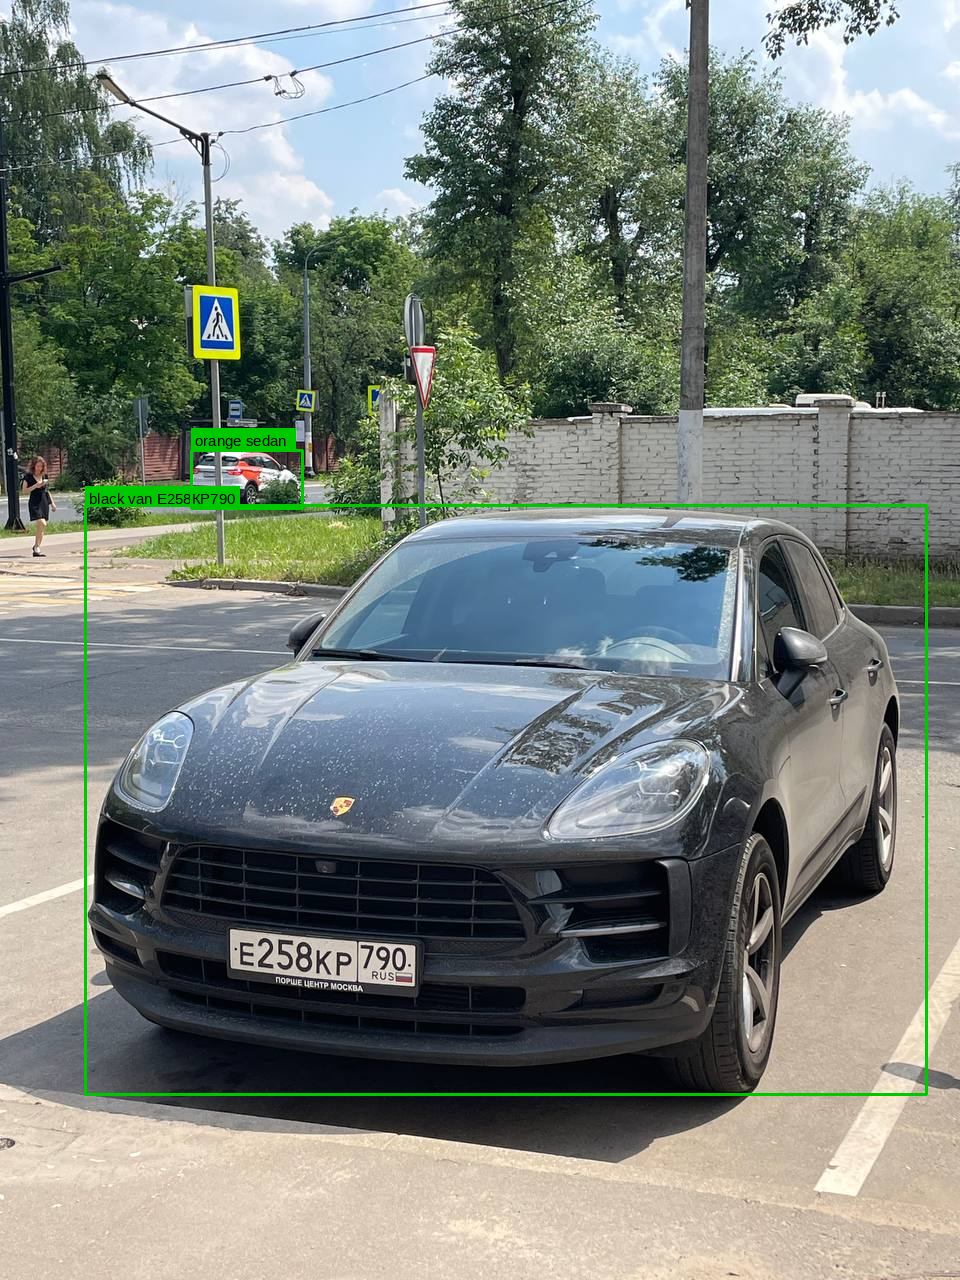

In [5]:
# ── Загрузка тестового изображения ────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()
TEST_IMG_PATH = list(uploaded.keys())[0]

frame = cv2.imread(TEST_IMG_PATH)
result_frame, detected = process_frame(frame)

print(f'Найдено объектов: {len(detected)}')
for v in detected:
    print(f'  {v["class"]:10s}  цвет={v["color"]} ({v["color_conf"]:.2f})  '
          f'кузов={v["body"]} ({v["body_conf"]:.2f})  номер={v["plate"]}')

cv2.imwrite(str(OUTPUT_DIR / 'test_single_frame.jpg'), result_frame)
cv2_imshow(result_frame)

## 4. Видео-инференс: трекинг + агрегация по машине

Покадровая обработка даёт сотни независимых детекций одной машины с шумными предсказаниями. Здесь — устойчивый подход:
- **Трекинг** (`model.track`, ByteTrack) — каждая машина получает стабильный `ID`: одна машина = одна итоговая карточка.
- **Агрегация по треку** — цвет и кузов голосованием по кадрам (взвешенно по уверенности/качеству), номер — самый частый regex-валидный OCR-результат.
- **Гейтинг качества** — номер читаем только с крупных кропов (`MIN_PLATE_W`), цвет и кузов — только с достаточно крупных авто; невалидные номера отбрасываются.
- **Диагностика** — показываем номерные кропы, которые видит OCR (ширина в px — предел читаемости).

Порядок запуска: загрузка видео → helper-функции → трекинг → галерея.

In [6]:
# ── Загрузка видео ────────────────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()                       # выберите видеофайл (MP4/MOV)
TEST_VIDEO_PATH = '/content/' + list(uploaded.keys())[0]
assert Path(TEST_VIDEO_PATH).exists(), f'Файл не найден: {TEST_VIDEO_PATH}'
print('Видео:', TEST_VIDEO_PATH)

Saving IMG_8427.MOV to IMG_8427.MOV
Видео: /content/IMG_8427.MOV


In [7]:
# ── Helper-функции для трекинг-инференса ─────────────────────────────────────
def predict_proba(model, crop_bgr):
    """Полный вектор вероятностей по классам (softmax) — для голосования по треку."""
    img = Image.fromarray(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
    with torch.no_grad():
        p = torch.softmax(model(INF_TF(img).unsqueeze(0).to(DEVICE)), dim=1)
    return p[0].cpu().numpy()

def laplacian_sharpness(img_bgr):
    """Резкость кропа = дисперсия Лапласиана (выбор лучшего кадра трека)."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())

def read_plate_strict(plate_crop, reader, min_width=60):
    """OCR номера БЕЗ фолбэка text[:9]: возвращает (текст, conf) только для
    regex-валидного РФ-номера, иначе ('', 0.0). Otsu убран — на мелких/смазанных
    номерах жёсткая бинаризация чаще вредит, чем помогает."""
    if plate_crop is None or plate_crop.size == 0:
        return '', 0.0
    h, w = plate_crop.shape[:2]
    if w < min_width:                       # слишком мелкий номер — не читаем
        return '', 0.0
    scale = max(1, 300 // max(w, 1))
    if scale > 1:
        plate_crop = cv2.resize(plate_crop, (w * scale, h * scale),
                                interpolation=cv2.INTER_CUBIC)
    gray   = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    result = reader.readtext(gray, detail=1, allowlist=_PLATE_ALLOWLIST)
    if not result:
        return '', 0.0
    result.sort(key=lambda r: (r[0][0][0] + r[0][2][0]) / 2)   # слева направо
    text = ''.join(r[1] for r in result).upper().replace(' ', '').translate(LATIN_TO_CYR)
    conf = float(np.mean([r[2] for r in result]))
    m = PLATE_REGEX.search(text)
    return (m.group(0), conf) if m else ('', 0.0)

print('Helper-функции трекинг-инференса определены.')


Helper-функции трекинг-инференса определены.


In [8]:
# ── Видео-инференс с трекингом и агрегацией по машине ─────────────────────────
from collections import defaultdict, Counter

TRACK_CONF       = 0.4    # порог детекции ТС
MIN_COLOR_BOX    = 80     # цвет считаем только если бОльшая сторона бокса ≥ этого (px)
MIN_PLATE_W      = 60     # не читаем номер уже этого (px), но самый широкий кроп всё равно сохраняем
MIN_BODY_BOX     = 128    # кузов классифицируем только если бОльшая сторона бокса ≥ этого (px)
BODY_CONF_MIN    = 0.45   # ниже — помечаем кузов как неуверенный (⚠)
MAX_OCR_PER_ID   = 20     # лимит OCR-попыток на одну машину
MIN_TRACK_FRAMES = 5      # отсекаем случайные короткие треки

# сброс трекера, если ячейку перезапускают (чтобы ID не накапливались)
try:
    vehicle_model.predictor.trackers[0].reset()
except Exception:
    pass

tracks = defaultdict(lambda: {
    'color_prob': np.zeros(len(COLOR_LABELS)), 'color_n': 0,
    'color_best_conf': 0.0, 'color_best_lbl': '',
    'body_prob':  np.zeros(len(BODY_LABELS)),  'body_n': 0,
    'plates': [], 'ocr_tries': 0,
    'best_crop': None, 'best_plate_crop': None, 'best_plate_w': 0, 'best_sharp': -1.0,
    'cls': 'vehicle', 'n': 0,
})

cap   = cv2.VideoCapture(TEST_VIDEO_PATH)
vid_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Видео: {vid_w}x{vid_h}, {total} кадров (читаем КАЖДЫЙ кадр)')
fidx, t0 = 0, time.time()
while True:
    ret, frame = cap.read()
    if not ret:
        break
    res   = vehicle_model.track(frame, persist=True, tracker='bytetrack.yaml',
                                conf=TRACK_CONF, classes=list(VEHICLE_CLASSES), verbose=False)
    boxes = res[0].boxes
    if boxes is not None and boxes.id is not None:
        for box in boxes:
            tid = int(box.id[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
            crop = frame[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            T = tracks[tid]
            T['n']   += 1
            T['cls']  = VEHICLE_CLASSES.get(int(box.cls[0]), 'vehicle')
            side      = max(x2 - x1, y2 - y1)
            # цвет — только с крупных кропов, вклад взвешен по уверенности кадра
            # (на мелких/тёмных кадрах silver сваливается в black и портит голосование)
            if side >= MIN_COLOR_BOX:
                cp = predict_proba(color_model, crop)
                ci = int(cp.argmax())
                T['color_prob'] += cp * cp[ci]
                T['color_n']    += 1
                if cp[ci] > T['color_best_conf']:
                    T['color_best_conf'] = float(cp[ci])
                    T['color_best_lbl']  = COLOR_LABELS[ci]
            # кузов — только для крупных авто
            if side >= MIN_BODY_BOX:
                T['body_prob'] += predict_proba(body_model, crop)
                T['body_n']    += 1
            # лучший (самый резкий) кроп всей машины — для галереи и фолбэка цвета
            s = laplacian_sharpness(crop)
            if s > T['best_sharp']:
                T['best_sharp'] = s
                T['best_crop']  = crop.copy()
            # номер: ВСЕГДА запоминаем самый широкий кроп (для диагностики предела),
            #        OCR — только если он крупный и не превышен лимит попыток
            pcrop = detect_plate(crop, plate_model)
            if pcrop is not None and pcrop.shape[1] > T['best_plate_w']:
                T['best_plate_w']    = pcrop.shape[1]
                T['best_plate_crop'] = pcrop.copy()
            if (pcrop is not None and pcrop.shape[1] >= MIN_PLATE_W
                    and T['ocr_tries'] < MAX_OCR_PER_ID):
                T['ocr_tries'] += 1
                txt, conf = read_plate_strict(pcrop, ocr_reader, MIN_PLATE_W)
                if txt:
                    T['plates'].append((txt, conf))
    fidx += 1
    if fidx % 60 == 0:
        print(f'  Кадр {fidx}/{total}  активных треков={len(tracks)}')
cap.release()
print(f'Готово за {time.time()-t0:.1f}s. Всего треков: {len(tracks)}')

# ── Агрегация по треку ───────────────────────────────────────────────────────
def agg_color(T):
    """Цвет машины: взвешенное голосование по крупным кадрам, иначе — лучший кадр."""
    if T['color_n'] > 0:
        cprob = T['color_prob'] / T['color_prob'].sum()
        ci    = int(cprob.argmax())
        return COLOR_LABELS[ci], float(cprob[ci]), False
    if T['best_crop'] is not None:               # машина всегда мелкая — по резкому кадру
        cp = predict_proba(color_model, T['best_crop']); ci = int(cp.argmax())
        return COLOR_LABELS[ci], float(cp[ci]), True
    return '?', 0.0, True

rows = []
for tid, T in sorted(tracks.items()):
    if T['n'] < MIN_TRACK_FRAMES:
        continue
    color, color_conf, color_fallback = agg_color(T)
    T['color'], T['color_conf'] = color, color_conf        # кладём обратно для галереи
    color_info = f"{color} ({color_conf:.2f})"
    if color_fallback:
        color_info += ' [по лучшему кадру]'
    elif T['color_best_lbl'] and T['color_best_lbl'] != color:
        color_info += f"; лучший кадр: {T['color_best_lbl']} {T['color_best_conf']:.2f}"
    if T['body_n'] > 0:
        bp    = T['body_prob'] / T['body_n']
        order = bp.argsort()[::-1]
        body_top1 = f"{BODY_LABELS[order[0]]} ({bp[order[0]]:.2f})"
        if bp[order[0]] < BODY_CONF_MIN:
            body_top1 += ' ⚠'
        body_top3 = ', '.join(f"{BODY_LABELS[i]} {bp[i]:.2f}" for i in order[:3])
    else:
        body_top1, body_top3 = 'n/a (мелкий)', '—'
    if T['plates']:
        cnt   = Counter(t for t, _ in T['plates'])
        plate = cnt.most_common(1)[0][0]
        plate_info = f"{plate}  (×{cnt[plate]} из {len(T['plates'])})"
    else:
        plate, plate_info = '', '—'
    rows.append({'id': tid, 'class': T['cls'], 'frames': T['n'],
                 'color': color, 'color_info': color_info,
                 'body_top1': body_top1, 'body_top3': body_top3,
                 'plate': plate, 'plate_px': T['best_plate_w'], 'plate_info': plate_info})

df_tracks = pd.DataFrame(rows)
n_valid = int((df_tracks['plate'] != '').sum()) if len(df_tracks) else 0
print(f'\nМашин после фильтра (≥{MIN_TRACK_FRAMES} кадров): {len(df_tracks)}')
print(f'С валидным номером (regex РФ): {n_valid}')
if len(df_tracks):
    print(f'Макс. ширина номера среди всех машин: {df_tracks["plate_px"].max()} px '
          f'(для надёжного OCR нужно ≳ {MIN_PLATE_W}-100 px)')
df_tracks[['id', 'class', 'frames', 'color_info', 'body_top1', 'plate', 'plate_px', 'plate_info']]


Видео: 1280x720, 630 кадров (читаем КАЖДЫЙ кадр)
  Кадр 60/630  активных треков=1
  Кадр 120/630  активных треков=1
  Кадр 180/630  активных треков=2
  Кадр 240/630  активных треков=3
  Кадр 300/630  активных треков=3
  Кадр 360/630  активных треков=4
  Кадр 420/630  активных треков=4
  Кадр 480/630  активных треков=4
  Кадр 540/630  активных треков=4
  Кадр 600/630  активных треков=4
Готово за 19.4s. Всего треков: 4

Машин после фильтра (≥5 кадров): 3
С валидным номером (regex РФ): 1
Макс. ширина номера среди всех машин: 131 px (для надёжного OCR нужно ≳ 60-100 px)


,id,class,frames,color_info,body_top1,plate,plate_px,plate_info
0,1,car,71,black (0.50),truck (0.31) ⚠,,71,—
1,4,car,249,black (0.54),van (0.25) ⚠,,83,—
2,5,car,291,silver (0.67),sedan (0.46),О947НХ150,131,О947НХ150 (×3 из 4)


Машин в галерее: 3


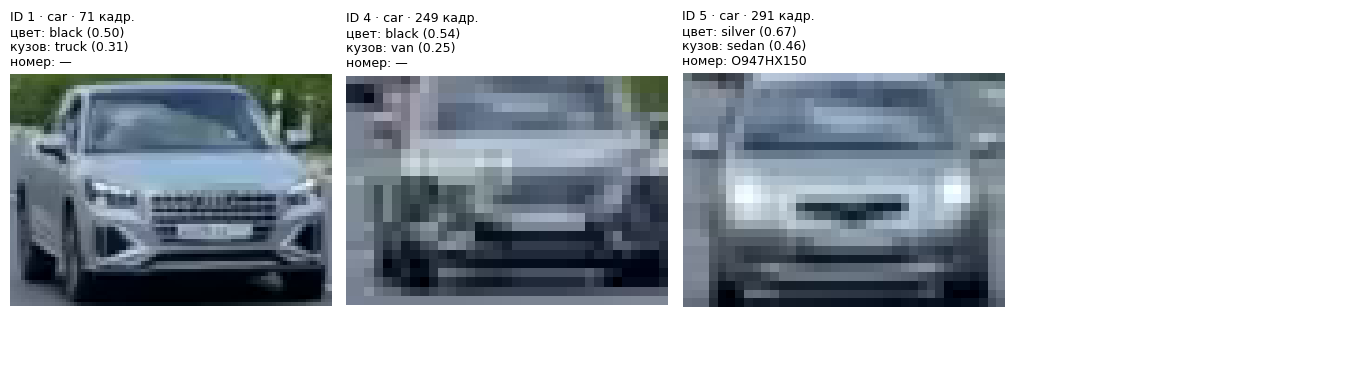

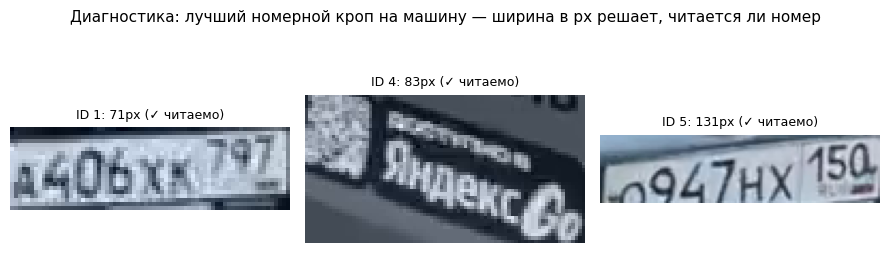

In [9]:
# ── Галерея: одна карточка на машину (лучший кадр) + что видел OCR ────────────
import math

items = [(tid, T) for tid, T in sorted(tracks.items())
         if T['n'] >= MIN_TRACK_FRAMES and T['best_crop'] is not None]
print(f'Машин в галерее: {len(items)}')

if items:
    cols   = 4
    rows_n = math.ceil(len(items) / cols)
    fig, axes = plt.subplots(rows_n, cols, figsize=(cols * 3.4, rows_n * 3.7))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis('off')
    for ax, (tid, T) in zip(axes, items):
        color = f"{T.get('color', '?')} ({T.get('color_conf', 0):.2f})"
        if T['body_n'] > 0:
            bp = T['body_prob'] / T['body_n']; bi = int(bp.argmax())
            body = f"{BODY_LABELS[bi]} ({bp[bi]:.2f})"
        else:
            body = 'n/a (мелкий)'
        plate = Counter(t for t, _ in T['plates']).most_common(1)[0][0] if T['plates'] else '—'
        ax.imshow(cv2.cvtColor(T['best_crop'], cv2.COLOR_BGR2RGB))
        ax.set_title(f"ID {tid} · {T['cls']} · {T['n']} кадр.\n"
                     f"цвет: {color}\nкузов: {body}\nномер: {plate}",
                     fontsize=9, loc='left')
    plt.tight_layout()
    plt.show()

    # ── Диагностика: самый широкий номерной кроп каждой машины (что видит OCR) ─
    pcs = [(tid, T['best_plate_crop'], T['best_plate_w'])
           for tid, T in items if T['best_plate_crop'] is not None]
    if pcs:
        fig, axes = plt.subplots(1, len(pcs), figsize=(len(pcs) * 3, 3))
        axes = np.atleast_1d(axes)
        for ax, (tid, crop, w) in zip(axes, pcs):
            ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)); ax.axis('off')
            ok = '✓ читаемо' if w >= MIN_PLATE_W else '✗ мелко'
            ax.set_title(f'ID {tid}: {w}px ({ok})', fontsize=9)
        plt.suptitle('Диагностика: лучший номерной кроп на машину — ширина в px '
                     'решает, читается ли номер', fontsize=11)
        plt.tight_layout()
        plt.show()
    else:
        print('Номерных кропов не нашлось — детектор номеров ничего не выделил.')


## 5. Размеченное видео

Сохраняем полное видео с рамками и подписями. В отличие от покадрового варианта,
подписи берутся **из агрегированных по треку** результатов (раздел 4), поэтому
у каждой машины стабильная метка `цвет + кузов + номер`, а не мелькающие
покадровые предсказания. Результат → `output_video.mp4` (+ автоскачивание в Colab).

In [10]:
# ── Размеченное видео: боксы + агрегированные подписи по каждому треку ────────
OUT_VIDEO = OUTPUT_DIR / 'output_video.mp4'

def track_caption(tid):
    """Подпись машины: агрегированные цвет/кузов/номер (стабильны по треку)."""
    T = tracks.get(tid)
    if T is None:
        return ''
    color = T.get('color', '?')
    body  = BODY_LABELS[int((T['body_prob'] / T['body_n']).argmax())] if T['body_n'] > 0 else '?'
    plate = Counter(t for t, _ in T['plates']).most_common(1)[0][0] if T['plates'] else ''
    return f'{color} {body} {plate}'.strip()

# чистый проход трекера (ID совпадут с предыдущей ячейкой — видео и параметры те же)
try:
    vehicle_model.predictor.trackers[0].reset()
except Exception:
    pass

cap    = cv2.VideoCapture(TEST_VIDEO_PATH)
w      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps_in = cap.get(cv2.CAP_PROP_FPS) or 25
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
out    = cv2.VideoWriter(str(OUT_VIDEO), cv2.VideoWriter_fourcc(*'mp4v'), fps_in, (w, h))

t0, n = time.time(), 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    res    = vehicle_model.track(frame, persist=True, tracker='bytetrack.yaml',
                                 conf=TRACK_CONF, classes=list(VEHICLE_CLASSES), verbose=False)
    boxes  = res[0].boxes
    canvas = frame.copy()
    if boxes is not None and boxes.id is not None:
        for box in boxes:
            tid = int(box.id[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
            cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 200, 0), 2)
            canvas = _draw_label_pil(canvas, x1, y1, track_caption(tid))
    out.write(canvas)
    n += 1
    if n % 60 == 0:
        print(f'  Кадр {n}/{total}')
cap.release(); out.release()
print(f'Готово за {time.time()-t0:.1f}s. Видео сохранено: {OUT_VIDEO}')

if IN_COLAB:
    from google.colab import files
    files.download(str(OUT_VIDEO))


  Кадр 60/630
  Кадр 120/630
  Кадр 180/630
  Кадр 240/630
  Кадр 300/630
  Кадр 360/630
  Кадр 420/630
  Кадр 480/630
  Кадр 540/630
  Кадр 600/630
Готово за 19.4s. Видео сохранено: diploma_04_pipeline/output/output_video.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>